# Intelligent Spam Classification & Threat Triage Platform
## Notebook 03 — Security Feature Engineering

This notebook evaluates the deterministic security-evidence layer built in `src/threat_triage/security/`.

The objective is to measure whether observable URL, sender, and social-engineering signals provide useful evidence beyond the classical TF-IDF + Logistic Regression baseline.

### Core Question

> **How many threats missed by the classical ML model still expose deterministic security evidence?**

This notebook connects:

**Classical ML Baseline → Deterministic Security Features → Hybrid Architecture Motivation**

## 1. Colab Environment Setup

Clone or pull the GitHub repository into Colab and install the project in editable mode.

Expected repository structure:

    intelligent-spam-threat-triage/
    ├── src/
    │   └── threat_triage/
    │       ├── data_loader.py
    │       └── security/
    │           ├── models.py
    │           ├── url_analyzer.py
    │           ├── sender_analyzer.py
    │           ├── language_analyzer.py
    │           └── feature_extractor.py
    ├── notebooks/
    ├── tests/
    ├── artifacts/
    └── pyproject.toml

In [23]:
%cd /content/intelligent-spam-threat-triage

%pip install -e .

import sys
from pathlib import Path

SRC_PATH = Path("/content/intelligent-spam-threat-triage/src")

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("Repository installed.")
print("Source path:", SRC_PATH)

/content/intelligent-spam-threat-triage
Obtaining file:///content/intelligent-spam-threat-triage
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for intelligent-spam-threat-triage (pyproject.toml) ... done
  Created wheel for intelligent-spam-threat-triage: filename=intelligent_spam_threat_triage-0.1.0-0.editable-py3-none-any.whl size=1607 sha256=e569e42231149effbce4de9752b19b0b4be0647dfca541d501580f861934bde9
  Stored in directory: /tmp/pip-ephem-wheel-cache-4y0x_k21/wheels/01/8b/ed/8a6f8d839a5a936d91b4556ad2764073068d9f2893d3749dd3
Successfully built intelligent-spam-threat-triage
  Attempting uninstall: intelligent-spam-threat-triage
    Found existing installation: intelligent-spam-threat-triage 0.1.0
    Uninstalling intelligent-spam-threat-triage-0.1.0:
      Successfully uninstalled intelligent-spam-th

In [24]:
import sys

print("Notebook Python:")
print(sys.executable)

print("\nPython paths containing site-packages or src:")
for path in sys.path:
    if "site-packages" in path or path.endswith("/src"):
        print(path)

Notebook Python:
/usr/bin/python3

Python paths containing site-packages or src:
/content/intelligent-spam-threat-triage/src


In [25]:
import threat_triage

print("threat_triage import: PASSED")
print("Loaded from:")
print(threat_triage.__file__)

threat_triage import: PASSED
Loaded from:
/content/intelligent-spam-threat-triage/src/threat_triage/__init__.py


In [26]:
from threat_triage.data_loader import (
    CANONICAL_COLUMNS,
    get_train_validation_test,
)

from threat_triage.security import (
    extract_security_features_from_record,
)

print("data_loader import: PASSED")
print("security package import: PASSED")
print("Notebook 03 production imports: PASSED")

data_loader import: PASSED
security package import: PASSED
Notebook 03 production imports: PASSED


## 2. Imports and Configuration

This notebook uses the production data loader and production security feature extractor. Feature logic is not duplicated inside the notebook.

In [27]:
from __future__ import annotations

import json
import re
from dataclasses import asdict
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from threat_triage.data_loader import (
    CANONICAL_COLUMNS,
    get_train_validation_test,
)

from threat_triage.security import (
    extract_security_features_from_record,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()

print("Project root:", PROJECT_ROOT)

Project root: /content/intelligent-spam-threat-triage


## 3. Load Canonical Dataset

Reuse the same split policy as Notebook 02:

- original train split → train + validation
- original test split → locked test

This keeps Notebook 03 aligned with the classical ML baseline.

In [28]:
splits = get_train_validation_test(
    validation_size=0.20,
    random_state=RANDOM_STATE,
)

train_df = splits.train
validation_df = splits.validation
test_df = splits.test

print("Train      :", train_df.shape)
print("Validation :", validation_df.shape)
print("Test       :", test_df.shape)

README.md:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B /  184MB            

train.parquet: downloading bytes:           |  0.00B            

test.parquet: reconstructing file:   0%|          |  0.00B / 22.7MB            

test.parquet: downloading bytes:           |  0.00B            

eval.parquet: reconstructing file:   0%|          |  0.00B / 22.7MB            

eval.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/162413 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/40604 [00:00<?, ? examples/s]

Train      : (129930, 12)
Validation : (32483, 12)
Test       : (40604, 12)


In [29]:
assert list(train_df.columns) == CANONICAL_COLUMNS
assert list(validation_df.columns) == CANONICAL_COLUMNS
assert list(test_df.columns) == CANONICAL_COLUMNS

print("Canonical schema validation: PASSED")

Canonical schema validation: PASSED


## 4. Deterministic Security Feature Extraction

The production feature extractor returns typed evidence grouped into:

- URL evidence
- Sender evidence
- Language / social-engineering evidence

For analysis, the nested evidence is flattened into tabular columns.

In [30]:
def flatten_security_features(features):
    data = asdict(features)

    return {
        "message_id": data["message_id"],

        "url_has_url": data["url"]["has_url"],
        "url_count": data["url"]["url_count"],
        "url_ip_address": data["url"]["uses_ip_address_url"],
        "url_shortener": data["url"]["uses_url_shortener"],
        "url_suspicious_tld": data["url"]["suspicious_tld"],
        "url_punycode": data["url"]["punycode_domain"],
        "url_excessive_subdomains": data["url"]["excessive_subdomains"],
        "url_domain_digits": data["url"]["domain_contains_digits"],
        "url_domain_hyphen": data["url"]["domain_contains_hyphen"],
        "url_credential_path": data["url"]["credential_path_keyword"],

        "sender_present": data["sender"]["sender_present"],
        "sender_domain": data["sender"]["sender_domain"],
        "sender_domain_digits": data["sender"]["sender_domain_has_digits"],
        "sender_domain_hyphen": data["sender"]["sender_domain_has_hyphen"],
        "sender_free_provider": data["sender"]["free_email_provider"],
        "sender_display_mismatch": data["sender"]["possible_display_name_mismatch"],

        "lang_urgency": data["language"]["urgency_language"],
        "lang_credentials": data["language"]["credential_request"],
        "lang_financial": data["language"]["financial_request"],
        "lang_verification": data["language"]["verification_request"],
        "lang_suspension": data["language"]["account_suspension_language"],
        "lang_password_reset": data["language"]["password_reset_language"],
    }

In [31]:
example_record = test_df.iloc[0].to_dict()

example_features = extract_security_features_from_record(
    example_record
)

flatten_security_features(example_features)

{'message_id': '5e75e66c2fbec6f63d4de7dcc54292dd93bf9875b2da81423bdd1897d8ba8157',
 'url_has_url': True,
 'url_count': 45,
 'url_ip_address': False,
 'url_shortener': False,
 'url_suspicious_tld': False,
 'url_punycode': False,
 'url_excessive_subdomains': True,
 'url_domain_digits': False,
 'url_domain_hyphen': True,
 'url_credential_path': False,
 'sender_present': True,
 'sender_domain': 'cns.bu.edu',
 'sender_domain_digits': False,
 'sender_domain_hyphen': False,
 'sender_free_provider': False,
 'sender_display_mismatch': False,
 'lang_urgency': False,
 'lang_credentials': False,
 'lang_financial': False,
 'lang_verification': False,
 'lang_suspension': False,
 'lang_password_reset': False}

## 5. Batch Feature Extraction

Start with the locked test set. This is enough to connect deterministic features to the Notebook 02 baseline and analyze false negatives.

In [32]:
def extract_feature_dataframe(dataframe):
    rows = []

    for record in dataframe.to_dict(orient="records"):
        features = extract_security_features_from_record(record)
        rows.append(flatten_security_features(features))

    return pd.DataFrame(rows)

In [33]:
test_security_df = extract_feature_dataframe(test_df)

print("Security feature shape:", test_security_df.shape)

test_security_df.head()

Security feature shape: (40604, 23)


,message_id,url_has_url,url_count,url_ip_address,url_shortener,url_suspicious_tld,url_punycode,url_excessive_subdomains,url_domain_digits,url_domain_hyphen,url_credential_path,sender_present,sender_domain,sender_domain_digits,sender_domain_hyphen,sender_free_provider,sender_display_mismatch,lang_urgency,lang_credentials,lang_financial,lang_verification,lang_suspension,lang_password_reset
0,5e75e66c2fbec6f63d4de7dcc54292dd93bf9875b2da81423bdd1897d8ba8157,True,45,False,False,False,False,True,False,True,False,True,cns.bu.edu,False,False,False,False,False,False,False,False,False,False
1,30218bf9ef36df63182b4510c0a37598b8042bdbefa9b9f93e9a52199d4c29f2,True,1,False,False,False,False,False,False,False,False,True,dsl.pipex.com,False,False,False,False,False,False,False,False,False,False
2,584ba3cd4e3a6a76ac406788f9fc4993bf515d4a2d5968d1a06b3a69bd3cd1a7,False,0,False,False,False,False,False,False,False,False,False,None,False,False,False,False,False,False,False,False,False,False
3,e3640caa646f7d5c3ff08e941ea7a5ff418a9bc5ecb5933ed2e6362801817f91,True,1,False,False,False,False,False,False,False,False,True,universetoday.com,False,False,False,False,False,False,False,False,False,False
4,8ad5ee08b40225e72bd761a87cb311fbf4e4c9011281cdcbc02d8b1e19c5adf4,True,1,False,False,False,False,False,False,False,False,True,surbl.org,False,False,False,False,False,False,False,False,False,False


In [35]:
print("test_df rows:", len(test_df))
print("test_security_df rows:", len(test_security_df))

print("\ntest_df unique message IDs:")
print(test_df["message_id"].nunique())

print("\ntest_security_df unique message IDs:")
print(test_security_df["message_id"].nunique())

print("\ntest_df duplicate message IDs:")
print(test_df["message_id"].duplicated().sum())

print("\ntest_security_df duplicate message IDs:")
print(
    test_security_df["message_id"]
    .duplicated()
    .sum()
)

test_df rows: 40604
test_security_df rows: 40604

test_df unique message IDs:
40586

test_security_df unique message IDs:
40586

test_df duplicate message IDs:
18

test_security_df duplicate message IDs:
18


In [36]:
duplicate_ids = (
    test_df.loc[
        test_df["message_id"].duplicated(keep=False),
        "message_id",
    ]
    .unique()
)

print("Duplicate message-id groups:", len(duplicate_ids))

test_df[
    test_df["message_id"].isin(duplicate_ids)
][
    [
        "message_id",
        "source_dataset",
        "subject",
        "canonical_label",
    ]
].sort_values("message_id").head(20)

Duplicate message-id groups: 17


,message_id,source_dataset,subject,canonical_label
1984,03505117b8f9a300a792358848c8a0a94ede45fa39d9f1515b7db12a4d2d5844,TREC-06,Pic and 68hc11board,BENIGN
2184,03505117b8f9a300a792358848c8a0a94ede45fa39d9f1515b7db12a4d2d5844,TREC-06,Pic and 68hc11board,BENIGN
35361,0649a9fb44369c4d07e3348e6063941c240d26fea640d686c66c688a3af751ac,TREC-06,Re: standalone plan9,BENIGN
5722,0649a9fb44369c4d07e3348e6063941c240d26fea640d686c66c688a3af751ac,TREC-06,Re: standalone plan9,BENIGN
30709,19e86dacbd04c8da3b4e7cd704e3984da2b139d44754bc1ef53f02dae6b4c115,TREC-07,New for You!,THREAT
36677,19e86dacbd04c8da3b4e7cd704e3984da2b139d44754bc1ef53f02dae6b4c115,TREC-07,New for You!,THREAT
3914,1b6340f8a9211f9dcb6daab4e25ceedb8a130cc80489adfe7f6a0a1f361dbf32,Enron,tadalafil soft tabs - great results !,THREAT
4923,1b6340f8a9211f9dcb6daab4e25ceedb8a130cc80489adfe7f6a0a1f361dbf32,Enron,tadalafil soft tabs - great results !,THREAT
8,2c6e31927aa4656342b7f5cffa9832284dfcd41b45b6eb5b80e4bbe0f624fcf6,TREC-05,Lunch Cardio Kick II Class Cancelled Today,BENIGN
12127,2c6e31927aa4656342b7f5cffa9832284dfcd41b45b6eb5b80e4bbe0f624fcf6,TREC-05,Lunch Cardio Kick II Class Cancelled Today,BENIGN


In [37]:
# Cell 10 — Join canonical metadata with extracted security features

assert len(test_df) == len(test_security_df)

# Feature extraction processes test_df records in exactly the same order.
# Verify that the deterministic IDs align row-by-row.
assert (
    test_df["message_id"]
    .reset_index(drop=True)
    .equals(
        test_security_df["message_id"]
        .reset_index(drop=True)
    )
)

canonical_columns = [
    "message_id",
    "canonical_label",
    "label_id",
    "source_dataset",
    "subject",
    "body",
    "sender",
]

security_columns = [
    column
    for column in test_security_df.columns
    if column != "message_id"
]

test_analysis = pd.concat(
    [
        test_df[canonical_columns]
        .reset_index(drop=True),

        test_security_df[security_columns]
        .reset_index(drop=True),
    ],
    axis=1,
)

print(
    "Joined analysis shape:",
    test_analysis.shape,
)

test_analysis.head()

Joined analysis shape: (40604, 29)


,message_id,canonical_label,label_id,source_dataset,subject,body,sender,url_has_url,url_count,url_ip_address,url_shortener,url_suspicious_tld,url_punycode,url_excessive_subdomains,url_domain_digits,url_domain_hyphen,url_credential_path,sender_present,sender_domain,sender_domain_digits,sender_domain_hyphen,sender_free_provider,sender_display_mismatch,lang_urgency,lang_credentials,lang_financial,lang_verification,lang_suspension,lang_password_reset
0,5e75e66c2fbec6f63d4de7dcc54292dd93bf9875b2da81423bdd1897d8ba8157,BENIGN,0,CEAS-08,[UAI] GRADUATE TRAINING IN THE DEPARTMENT OF COGNITIVE AND NEURAL SYSTEMS (CNS) AT BOSTON UNIVERSITY,************************************************************************\nGRADUATE TRAINING IN THE DEPARTMENT OF COGNITIVE AND NEURAL SYSTEMS \n(CNS) AT BOS...,BU CNS Department <ztg@cns.bu.edu>,True,45,False,False,False,False,True,False,True,False,True,cns.bu.edu,False,False,False,False,False,False,False,False,False,False
1,30218bf9ef36df63182b4510c0a37598b8042bdbefa9b9f93e9a52199d4c29f2,BENIGN,0,CEAS-08,Re: [opensuse] Online update,"Monkey 9 wrote: \n> https://bugzilla.novell.com/show_bug.cgi?id=360518\n\nThank you for taking the time to reply, but unfortunately not much at\nthat url me...",Peter Bradley <e.obrpygc@dsl.pipex.com>,True,1,False,False,False,False,False,False,False,False,True,dsl.pipex.com,False,False,False,False,False,False,False,False,False,False
2,584ba3cd4e3a6a76ac406788f9fc4993bf515d4a2d5968d1a06b3a69bd3cd1a7,THREAT,1,Enron,best online tablets here,"divorce benelux marcy somers vocable ca phi calcine crosslink contagion\nget any prescription drug you want !\nsimple , quick and affordable !\nwe deliver q...",None,False,0,False,False,False,False,False,False,False,False,False,None,False,False,False,False,False,False,False,False,False,False
3,e3640caa646f7d5c3ff08e941ea7a5ff418a9bc5ecb5933ed2e6362801817f91,THREAT,1,CEAS-08,"Produce Stronger, Rock Hard Erections.","Get your free bottles today, and change your life - why wait?\n\nSize DOES matter - change your life today!\n\nhttp://fronthigh.com/",Winifred Bragg <WinifredreedyHuerta@universetoday.com>,True,1,False,False,False,False,False,False,False,False,True,universetoday.com,False,False,False,False,False,False,False,False,False,False
4,8ad5ee08b40225e72bd761a87cb311fbf4e4c9011281cdcbc02d8b1e19c5adf4,BENIGN,0,CEAS-08,Re: what are the criteria for being listed in\tsa-blacklist.current?,"Also, the sa-blacklist inclusion policy is at:\n\n http://www.stearns.org/sa-blacklist/README.policy\n\nJeff C.",Jeff Chan <ociwu@surbl.org>,True,1,False,False,False,False,False,False,False,False,True,surbl.org,False,False,False,False,False,False,False,False,False,False


## 6. Security Feature Schema Validation

In [38]:
assert len(test_analysis) == len(test_df)

assert (
    test_analysis["message_id"]
    .reset_index(drop=True)
    .equals(
        test_df["message_id"]
        .reset_index(drop=True)
    )
)

print(
    "Analysis rows:",
    len(test_analysis),
)

print(
    "Duplicate message IDs:",
    test_analysis["message_id"]
    .duplicated()
    .sum(),
)

print(
    "Missing security features:",
    test_analysis["url_has_url"]
    .isna()
    .sum(),
)

print("Security feature alignment: PASSED")

Analysis rows: 40604
Duplicate message IDs: 18
Missing security features: 0
Security feature alignment: PASSED


In [40]:
SECURITY_SIGNAL_COLUMNS = [
    "url_has_url",
    "url_ip_address",
    "url_shortener",
    "url_suspicious_tld",
    "url_punycode",
    "url_excessive_subdomains",
    "url_domain_digits",
    "url_domain_hyphen",
    "url_credential_path",
    "sender_domain_digits",
    "sender_domain_hyphen",
    "sender_free_provider",
    "sender_display_mismatch",
    "lang_urgency",
    "lang_credentials",
    "lang_financial",
    "lang_verification",
    "lang_suspension",
    "lang_password_reset",
]

print("Security signals:", len(SECURITY_SIGNAL_COLUMNS))

Security signals: 19


# 7. Univariate Security Signal Analysis

Measure overall prevalence of each deterministic security signal.

In [41]:
signal_prevalence = (
    test_analysis[SECURITY_SIGNAL_COLUMNS]
    .mean()
    .sort_values(ascending=False)
    .to_frame("prevalence")
)

signal_prevalence["percentage"] = (
    signal_prevalence["prevalence"] * 100
).round(2)

signal_prevalence

,prevalence,percentage
url_has_url,0.424121,42.41
sender_free_provider,0.067284,6.73
url_domain_hyphen,0.059920,5.99
lang_urgency,0.050783,5.08
sender_domain_hyphen,0.040833,4.08
sender_domain_digits,0.040489,4.05
lang_financial,0.039602,3.96
url_domain_digits,0.039503,3.95
lang_credentials,0.022978,2.30
url_credential_path,0.014555,1.46


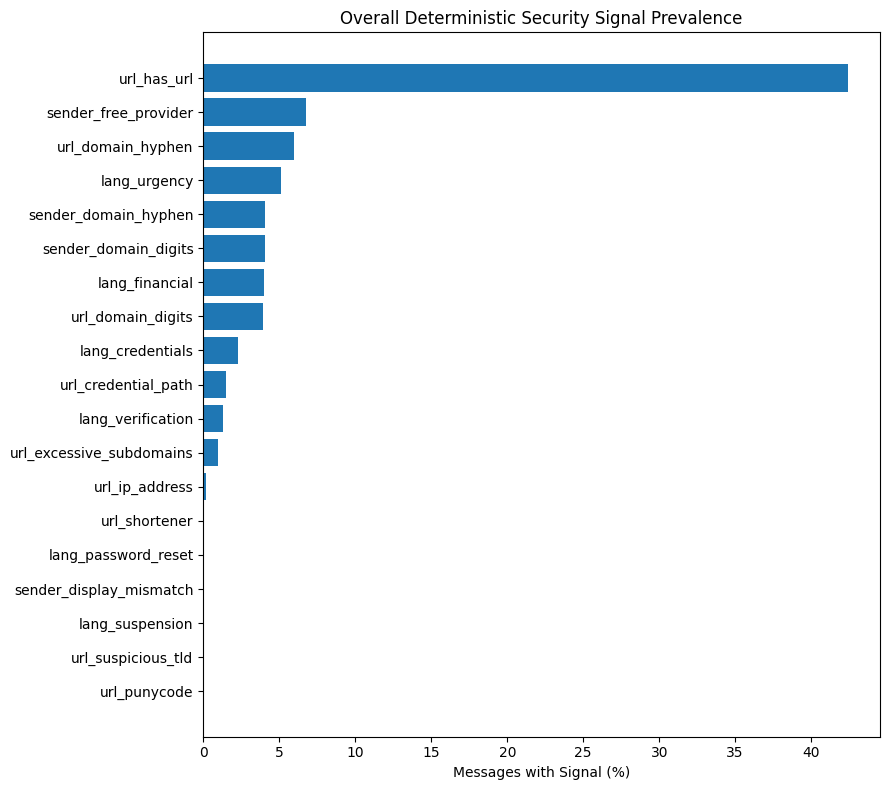

In [42]:
plot_df = signal_prevalence.sort_values("percentage")

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_df.index, plot_df["percentage"])
ax.set_xlabel("Messages with Signal (%)")
ax.set_title("Overall Deterministic Security Signal Prevalence")

plt.tight_layout()
plt.show()

# 8. BENIGN vs THREAT Security Signal Analysis

Compare prevalence by canonical class and calculate the percentage-point difference.

In [43]:
class_signal_rates = (
    test_analysis
    .groupby("canonical_label")[SECURITY_SIGNAL_COLUMNS]
    .mean()
    .T
)

class_signal_rates["BENIGN_pct"] = (
    class_signal_rates.get("BENIGN", 0) * 100
)

class_signal_rates["THREAT_pct"] = (
    class_signal_rates.get("THREAT", 0) * 100
)

class_signal_rates["difference_pct_points"] = (
    class_signal_rates["THREAT_pct"]
    - class_signal_rates["BENIGN_pct"]
)

class_signal_comparison = (
    class_signal_rates[
        [
            "BENIGN_pct",
            "THREAT_pct",
            "difference_pct_points",
        ]
    ]
    .sort_values("difference_pct_points", ascending=False)
    .round(2)
)

class_signal_comparison

canonical_label,BENIGN_pct,THREAT_pct,difference_pct_points
url_has_url,40.42,44.71,4.29
sender_domain_digits,2.52,5.81,3.30
url_domain_digits,2.48,5.64,3.16
sender_domain_hyphen,2.70,5.68,2.99
lang_financial,3.01,5.06,2.05
lang_urgency,4.18,6.11,1.93
url_ip_address,0.08,0.23,0.15
sender_display_mismatch,0.01,0.06,0.04
lang_suspension,0.01,0.04,0.03
url_suspicious_tld,0.01,0.01,0.00


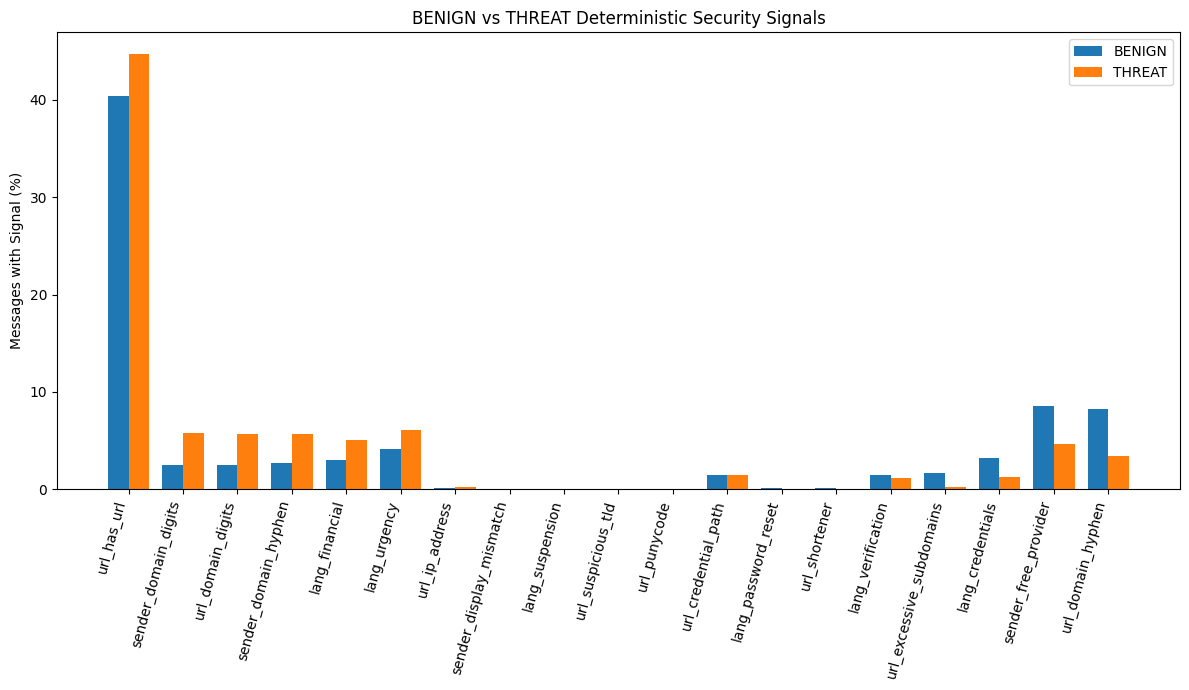

In [44]:
plot_df = class_signal_comparison.copy()

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(
    x - width / 2,
    plot_df["BENIGN_pct"],
    width,
    label="BENIGN",
)

ax.bar(
    x + width / 2,
    plot_df["THREAT_pct"],
    width,
    label="THREAT",
)

ax.set_xticks(x, labels=plot_df.index, rotation=75, ha="right")
ax.set_ylabel("Messages with Signal (%)")
ax.set_title("BENIGN vs THREAT Deterministic Security Signals")
ax.legend()

plt.tight_layout()
plt.show()

# 9. URL Security Signal Analysis

In [45]:
URL_SIGNAL_COLUMNS = [
    "url_has_url",
    "url_ip_address",
    "url_shortener",
    "url_suspicious_tld",
    "url_punycode",
    "url_excessive_subdomains",
    "url_domain_digits",
    "url_domain_hyphen",
    "url_credential_path",
]

url_comparison = (
    test_analysis
    .groupby("canonical_label")[URL_SIGNAL_COLUMNS]
    .mean()
    .T
    .mul(100)
    .round(2)
)

url_comparison

canonical_label,BENIGN,THREAT
url_has_url,40.42,44.71
url_ip_address,0.08,0.23
url_shortener,0.11,0.01
url_suspicious_tld,0.01,0.01
url_punycode,0.00,0.00
url_excessive_subdomains,1.70,0.18
url_domain_digits,2.48,5.64
url_domain_hyphen,8.23,3.42
url_credential_path,1.47,1.44


# 10. Sender Security Signal Analysis

In [46]:
SENDER_SIGNAL_COLUMNS = [
    "sender_present",
    "sender_domain_digits",
    "sender_domain_hyphen",
    "sender_free_provider",
    "sender_display_mismatch",
]

sender_comparison = (
    test_analysis
    .groupby("canonical_label")[SENDER_SIGNAL_COLUMNS]
    .mean()
    .T
    .mul(100)
    .round(2)
)

sender_comparison

canonical_label,BENIGN,THREAT
sender_present,82.09,82.21
sender_domain_digits,2.52,5.81
sender_domain_hyphen,2.70,5.68
sender_free_provider,8.57,4.61
sender_display_mismatch,0.01,0.06


# 11. Language / Social-Engineering Analysis

In [47]:
LANGUAGE_SIGNAL_COLUMNS = [
    "lang_urgency",
    "lang_credentials",
    "lang_financial",
    "lang_verification",
    "lang_suspension",
    "lang_password_reset",
]

language_comparison = (
    test_analysis
    .groupby("canonical_label")[LANGUAGE_SIGNAL_COLUMNS]
    .mean()
    .T
    .mul(100)
    .round(2)
)

language_comparison

canonical_label,BENIGN,THREAT
lang_urgency,4.18,6.11
lang_credentials,3.24,1.21
lang_financial,3.01,5.06
lang_verification,1.46,1.16
lang_suspension,0.01,0.04
lang_password_reset,0.08,0.00


# 12. Per-Source Security Signal Analysis

Notebook 02 showed strong source-level variation. Measure deterministic feature prevalence across each source corpus.

In [48]:
SELECTED_SOURCE_SIGNALS = [
    "url_has_url",
    "url_credential_path",
    "url_domain_digits",
    "sender_domain_hyphen",
    "lang_urgency",
    "lang_credentials",
    "lang_verification",
    "lang_suspension",
    "lang_password_reset",
]

source_signal_rates = (
    test_analysis
    .groupby("source_dataset")[SELECTED_SOURCE_SIGNALS]
    .mean()
    .mul(100)
    .round(2)
)

source_signal_rates

,url_has_url,url_credential_path,url_domain_digits,sender_domain_hyphen,lang_urgency,lang_credentials,lang_verification,lang_suspension,lang_password_reset
source_dataset,,,,,,,,,
Assassin,80.08,1.97,6.64,2.21,6.48,3.85,1.39,0.00,0.00
CEAS-08,67.13,3.90,3.66,6.88,2.25,1.89,1.04,0.00,0.02
Enron,0.00,0.00,0.00,0.00,7.20,1.89,1.76,0.00,0.05
Ling,0.00,0.00,0.00,0.00,8.10,0.70,1.23,0.00,0.00
TREC-05,31.21,1.16,4.98,3.25,6.87,2.65,1.76,0.04,0.12
TREC-06,39.49,1.34,8.82,6.75,4.59,1.83,1.55,0.15,0.00
TREC-07,57.43,0.80,3.72,4.70,4.05,2.52,0.77,0.01,0.00


# 13. Signal Co-occurrence Analysis

Single indicators may be weak. Count how many independent deterministic signals occur together.

In [49]:
test_analysis["url_signal_count"] = (
    test_analysis[
        [
            "url_ip_address",
            "url_shortener",
            "url_suspicious_tld",
            "url_punycode",
            "url_excessive_subdomains",
            "url_domain_digits",
            "url_domain_hyphen",
            "url_credential_path",
        ]
    ]
    .astype(int)
    .sum(axis=1)
)

test_analysis["sender_signal_count"] = (
    test_analysis[
        [
            "sender_domain_digits",
            "sender_domain_hyphen",
            "sender_free_provider",
            "sender_display_mismatch",
        ]
    ]
    .astype(int)
    .sum(axis=1)
)

test_analysis["language_signal_count"] = (
    test_analysis[LANGUAGE_SIGNAL_COLUMNS]
    .astype(int)
    .sum(axis=1)
)

test_analysis["total_security_signal_count"] = (
    test_analysis["url_signal_count"]
    + test_analysis["sender_signal_count"]
    + test_analysis["language_signal_count"]
)

test_analysis[
    [
        "canonical_label",
        "url_signal_count",
        "sender_signal_count",
        "language_signal_count",
        "total_security_signal_count",
    ]
].head()

,canonical_label,url_signal_count,sender_signal_count,language_signal_count,total_security_signal_count
0,BENIGN,2,0,0,2
1,BENIGN,0,0,0,0
2,THREAT,0,0,0,0
3,THREAT,0,0,0,0
4,BENIGN,0,0,0,0


In [50]:
signal_count_summary = (
    test_analysis
    .groupby("canonical_label")[
        [
            "url_signal_count",
            "sender_signal_count",
            "language_signal_count",
            "total_security_signal_count",
        ]
    ]
    .agg(["mean", "median", "max"])
    .round(2)
)

signal_count_summary

url_signal_count            sender_signal_count             \
                            mean median max                mean median max   
canonical_label                                                              
BENIGN                      0.14    0.0   4                0.14    0.0   2   
THREAT                      0.11    0.0   4                0.16    0.0   2   

                language_signal_count            total_security_signal_count  \
                                 mean median max                        mean   
canonical_label                                                                
BENIGN                           0.12    0.0   3                        0.40   
THREAT                           0.14    0.0   5                        0.41   

                            
                median max  
canonical_label             
BENIGN             0.0   7  
THREAT             0.0   6

In [51]:
rows = []

for label in ["BENIGN", "THREAT"]:
    subset = test_analysis[
        test_analysis["canonical_label"] == label
    ]

    for threshold in range(1, 7):
        rate = (
            subset["total_security_signal_count"] >= threshold
        ).mean()

        rows.append(
            {
                "class": label,
                "minimum_signal_count": threshold,
                "percentage": round(rate * 100, 2),
            }
        )

signal_threshold_table = pd.DataFrame(rows)

signal_threshold_table

,class,minimum_signal_count,percentage
0,BENIGN,1,30.85
1,BENIGN,2,7.43
2,BENIGN,3,1.26
3,BENIGN,4,0.25
4,BENIGN,5,0.05
5,BENIGN,6,0.01
6,THREAT,1,30.12
7,THREAT,2,7.66
8,THREAT,3,2.00
9,THREAT,4,0.76


# 14. Composite Evidence Analysis

These combinations are exploratory evidence only, not a risk score.

In [52]:
test_analysis["evidence_url_plus_credentials"] = (
    test_analysis["url_has_url"]
    & test_analysis["lang_credentials"]
)

test_analysis["evidence_verify_plus_credentials"] = (
    test_analysis["lang_verification"]
    & test_analysis["lang_credentials"]
)

test_analysis["evidence_suspension_plus_urgency"] = (
    test_analysis["lang_suspension"]
    & test_analysis["lang_urgency"]
)

test_analysis["evidence_url_path_plus_credentials"] = (
    test_analysis["url_credential_path"]
    & test_analysis["lang_credentials"]
)

COMPOSITE_COLUMNS = [
    "evidence_url_plus_credentials",
    "evidence_verify_plus_credentials",
    "evidence_suspension_plus_urgency",
    "evidence_url_path_plus_credentials",
]

composite_comparison = (
    test_analysis
    .groupby("canonical_label")[COMPOSITE_COLUMNS]
    .mean()
    .T
    .mul(100)
    .round(2)
)

composite_comparison

canonical_label,BENIGN,THREAT
evidence_url_plus_credentials,2.24,0.60
evidence_verify_plus_credentials,0.16,0.23
evidence_suspension_plus_urgency,0.00,0.03
evidence_url_path_plus_credentials,0.32,0.14


# 15. ML Baseline Integration

Notebook 02 saved the fitted model and selected threshold.

Expected paths:

- `artifacts/ml_baseline/tfidf_logistic_regression.joblib`
- `artifacts/ml_baseline/metrics.json`

If generated artifacts are excluded from Git, copy them into Colab or rerun Notebook 02 before continuing.

In [53]:
MODEL_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "ml_baseline"
    / "tfidf_logistic_regression.joblib"
)

METRICS_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "ml_baseline"
    / "metrics.json"
)

print("Model exists  :", MODEL_PATH.exists())
print("Metrics exists:", METRICS_PATH.exists())

Model exists  : True
Metrics exists: True


In [54]:
baseline_model = None
SELECTED_THRESHOLD = None

if MODEL_PATH.exists() and METRICS_PATH.exists():
    baseline_model = joblib.load(MODEL_PATH)

    with open(
        METRICS_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        baseline_metrics = json.load(file)

    SELECTED_THRESHOLD = float(
        baseline_metrics["selected_threshold"]
    )

    print("Loaded selected threshold:", SELECTED_THRESHOLD)

else:
    print(
        "Baseline artifacts not found. "
        "ML false-negative sections require Notebook 02 artifacts."
    )

Loaded selected threshold: 0.7363830677874296


# 16. Recreate Locked-Test ML Predictions

In [56]:
if baseline_model is not None:
    test_probability = baseline_model.predict_proba(
        test_df["combined_text"]
    )[:, 1]

    test_prediction = (
        test_probability >= SELECTED_THRESHOLD
    ).astype(int)

    # Ensure row counts align exactly.
    assert len(test_analysis) == len(test_df)
    assert len(test_probability) == len(test_df)
    assert len(test_prediction) == len(test_df)

    # Attach ML outputs by row position rather than message_id.
    test_analysis = test_analysis.reset_index(drop=True)

    test_analysis["ml_threat_probability"] = (
        test_probability
    )

    test_analysis["ml_prediction"] = (
        test_prediction
    )

    print("Predictions attached successfully.")
    print("Analysis shape:", test_analysis.shape)

else:
    print("Skipped: baseline model unavailable.")

Predictions attached successfully.
Analysis shape: (40604, 39)


In [57]:
assert len(test_analysis) == 40604

assert test_analysis[
    "ml_threat_probability"
].notna().all()

assert test_analysis[
    "ml_prediction"
].notna().all()

print("ML prediction alignment: PASSED")

ML prediction alignment: PASSED


# 17. ML False-Negative Security Analysis

A false negative is:

**Actual = THREAT**

**ML Prediction = BENIGN**

The goal is to determine whether deterministic security evidence exists in messages the classical model missed.

In [58]:
if baseline_model is not None:
    false_negatives = test_analysis[
        (test_analysis["label_id"] == 1)
        & (test_analysis["ml_prediction"] == 0)
    ].copy()

    print("ML false negatives:", len(false_negatives))
else:
    false_negatives = pd.DataFrame()
    print("Skipped: baseline model unavailable.")

ML false negatives: 957


In [59]:
if len(false_negatives) > 0:
    fn_signal_prevalence = (
        false_negatives[SECURITY_SIGNAL_COLUMNS]
        .mean()
        .sort_values(ascending=False)
        .to_frame("false_negative_rate")
    )

    fn_signal_prevalence["percentage"] = (
        fn_signal_prevalence["false_negative_rate"] * 100
    ).round(2)

    display(fn_signal_prevalence)

,false_negative_rate,percentage
url_has_url,0.253918,25.39
sender_domain_digits,0.070010,7.00
sender_domain_hyphen,0.067921,6.79
lang_urgency,0.058516,5.85
lang_credentials,0.055381,5.54
lang_financial,0.049112,4.91
sender_free_provider,0.041797,4.18
url_domain_digits,0.028213,2.82
url_domain_hyphen,0.024033,2.40
url_credential_path,0.011494,1.15


# 18. Recoverability Analysis

This does not claim the rules correctly classify false negatives.

It measures whether ML-missed threats contain enough deterministic evidence to justify deeper hybrid analysis.

In [60]:
if len(false_negatives) > 0:
    false_negatives["has_url_security_evidence"] = (
        false_negatives[
            [
                "url_ip_address",
                "url_shortener",
                "url_suspicious_tld",
                "url_punycode",
                "url_excessive_subdomains",
                "url_domain_digits",
                "url_domain_hyphen",
                "url_credential_path",
            ]
        ]
        .any(axis=1)
    )

    false_negatives["has_language_security_evidence"] = (
        false_negatives[LANGUAGE_SIGNAL_COLUMNS]
        .any(axis=1)
    )

    false_negatives["has_sender_security_evidence"] = (
        false_negatives[
            [
                "sender_domain_digits",
                "sender_domain_hyphen",
                "sender_display_mismatch",
            ]
        ]
        .any(axis=1)
    )

    false_negatives["hybrid_escalation_candidate"] = (
        false_negatives[
            [
                "has_url_security_evidence",
                "has_language_security_evidence",
                "has_sender_security_evidence",
            ]
        ]
        .any(axis=1)
        |
        (
            false_negatives["total_security_signal_count"]
            >= 2
        )
    )

In [77]:
false_negatives[
    "broad_escalation_candidate"
] = (
    false_negatives[
        [
            "has_url_security_evidence",
            "has_language_security_evidence",
            "has_sender_security_evidence",
        ]
    ].any(axis=1)
)


false_negatives[
    "strong_escalation_candidate"
] = (
    false_negatives[
        [
            "url_ip_address",
            "url_suspicious_tld",
            "url_punycode",
            "url_credential_path",
            "sender_display_mismatch",
            "lang_urgency",
            "lang_financial",
            "lang_suspension",
        ]
    ].any(axis=1)
    |
    (
        false_negatives[
            "total_security_signal_count"
        ] >= 2
    )
)

In [78]:
recovery_summary = pd.Series(
    {
        "false_negatives": len(false_negatives),

        "with_url_security_evidence": int(
            false_negatives[
                "has_url_security_evidence"
            ].sum()
        ),

        "with_language_security_evidence": int(
            false_negatives[
                "has_language_security_evidence"
            ].sum()
        ),

        "with_sender_security_evidence": int(
            false_negatives[
                "has_sender_security_evidence"
            ].sum()
        ),

        "broad_escalation_candidates": int(
            false_negatives[
                "broad_escalation_candidate"
            ].sum()
        ),

        "broad_candidate_percentage": (
            false_negatives[
                "broad_escalation_candidate"
            ].mean()
            * 100
        ),

        "strong_escalation_candidates": int(
            false_negatives[
                "strong_escalation_candidate"
            ].sum()
        ),

        "strong_candidate_percentage": (
            false_negatives[
                "strong_escalation_candidate"
            ].mean()
            * 100
        ),
    }
)

display(
    recovery_summary.round(2)
)

,0
false_negatives,957.00
with_url_security_evidence,52.00
with_language_security_evidence,149.00
with_sender_security_evidence,128.00
broad_escalation_candidates,283.00
broad_candidate_percentage,29.57
strong_escalation_candidates,141.00
strong_candidate_percentage,14.73


## 18.1 Recoverability by Source Dataset

In [70]:
if len(false_negatives) > 0:
    source_recovery = (
        false_negatives
        .groupby("source_dataset")
        .agg(
            false_negatives=("message_id", "size"),
            escalation_candidates=(
                "hybrid_escalation_candidate",
                "sum",
            ),
        )
    )

    source_recovery["candidate_percentage"] = (
        source_recovery["escalation_candidates"]
        / source_recovery["false_negatives"]
        * 100
    ).round(2)

    display(
        source_recovery.sort_values(
            "candidate_percentage",
            ascending=False,
        )
    )

,false_negatives,escalation_candidates,candidate_percentage
source_dataset,,,
Assassin,36,19,52.78
TREC-05,292,100,34.25
TREC-06,66,22,33.33
TREC-07,362,110,30.39
Ling,20,6,30.00
CEAS-08,36,6,16.67
Enron,145,20,13.79


# 19. ML False-Positive Analysis

Measure deterministic signal prevalence among BENIGN messages incorrectly classified as THREAT.

In [63]:
if baseline_model is not None:
    false_positives = test_analysis[
        (test_analysis["label_id"] == 0)
        & (test_analysis["ml_prediction"] == 1)
    ].copy()

    print("ML false positives:", len(false_positives))
else:
    false_positives = pd.DataFrame()

ML false positives: 118


In [71]:
if len(false_positives) > 0:
    fp_signal_prevalence = (
        false_positives[SECURITY_SIGNAL_COLUMNS]
        .mean()
        .sort_values(ascending=False)
        .to_frame("false_positive_rate")
    )

    fp_signal_prevalence["percentage"] = (
        fp_signal_prevalence["false_positive_rate"]
        * 100
    ).round(2)

    display(fp_signal_prevalence)

,false_positive_rate,percentage
url_has_url,0.415254,41.53
lang_credentials,0.076271,7.63
sender_domain_hyphen,0.059322,5.93
sender_free_provider,0.050847,5.08
lang_financial,0.050847,5.08
lang_urgency,0.042373,4.24
url_domain_digits,0.042373,4.24
url_domain_hyphen,0.042373,4.24
url_credential_path,0.042373,4.24
sender_domain_digits,0.033898,3.39


# 20. Safe Explainability Examples

Inspect a small number of ML false negatives that expose deterministic evidence.

URLs are defanged in display output. Do not visit dataset URLs.

In [65]:
def sanitize_preview(value, max_chars=350):
    if value is None:
        return ""

    text = str(value)
    text = text.replace("\r", " ").replace("\n", " ")

    text = re.sub(
        r"(?i)https?://",
        lambda match: (
            "hxxps://"
            if match.group(0).lower().startswith("https")
            else "hxxp://"
        ),
        text,
    )

    text = re.sub(r"\s+", " ", text).strip()

    if len(text) > max_chars:
        text = text[:max_chars] + "..."

    return text

In [72]:
if len(false_negatives) > 0:
    evidence_examples = (
        false_negatives[
            false_negatives["hybrid_escalation_candidate"]
        ]
        .sort_values(
            [
                "total_security_signal_count",
                "ml_threat_probability",
            ],
            ascending=[False, True],
        )
        .head(10)
        .copy()
    )

    example_columns = [
        "source_dataset",
        "subject",
        "body",
        "sender",
        "ml_threat_probability",
        "total_security_signal_count",
        "url_credential_path",
        "sender_display_mismatch",
        "lang_urgency",
        "lang_credentials",
        "lang_verification",
        "lang_suspension",
        "lang_password_reset",
    ]

    examples = evidence_examples[example_columns].copy()

    examples["subject"] = examples["subject"].apply(
        lambda value: sanitize_preview(value, 120)
    )

    examples["body"] = examples["body"].apply(
        lambda value: sanitize_preview(value, 350)
    )

    display(examples)

,source_dataset,subject,body,sender,ml_threat_probability,total_security_signal_count,url_credential_path,sender_display_mismatch,lang_urgency,lang_credentials,lang_verification,lang_suspension,lang_password_reset
40454,TREC-05,Your Florist web site is NOT being SEEN!,Dear Harry Here is the detaisl I spoke of. Your Florist WebiSite is NOT Being SEEN! WHY? NO ONE CAN FIND IT! YOUR web site is NOT on manyisearchi engines an...,Important Message! <rockwelldat@yahoo.co.uk>,0.719023,5,False,False,True,False,False,False,False
13916,TREC-05,E-mail address change. Please verify your request.,You have added laptopseller@yahoo.com as a new email address for your PayPal account. If you did not authorize this change or if you need assistance with yo...,Paypal Change <change@paypal.com>,0.693147,4,True,False,False,True,True,False,False
7759,TREC-05,Introducing Morpheus 2.0!,MSC_2391.gif Be your own Boss and Work from Home. Click here to get FREE Information on how you can make up to $4000 per Week!! Click Here! WELCOME!!! Welco...,morpheus@inyouremail.com,0.404977,3,False,False,True,True,False,False,False
8484,TREC-07,failure notice,Hi. This is the qmail-send program at ma1-us.server.dhamma.org. I'm afraid I wasn't able to deliver your message to the following addresses. This is a perma...,MAILER-DAEMON@ma1-us.server.dhamma.org,0.459070,3,False,False,False,False,True,False,False
4203,TREC-06,Important Notice!,"IMPORTANT NOTICE Dear Halifax Customer, This mail is to inform you about the important urgent updates of our service you are requested to please follow the ...",Halifax Online Banking <accounts@halifax.co.uk>,0.581787,3,True,False,True,False,False,False,False
3166,TREC-05,"Call in Your Email Messages, To-Do's and More",~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Palm Solutions brought to you by InSync Online ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~...,InSync Online <InSyncOnline.6qgcyx0w.d@insync-palm.com>,0.593902,3,False,False,False,False,False,False,False
36038,TREC-05,Account compromised: billing information moved or changed.,"LEGAL NOTICE The following message is an email sent to you by an administrator of ""PayPal.com"".If this message is spam, contains abusive or other comments y...",PayPal <aw-confirm@paypal.com>,0.597802,3,True,False,True,False,False,False,False
458,TREC-06,FROM THE DIESK OF JEFF MIKE (URGENCY),"FROM THE DIESK OF JEFF MIKE ATTENTION PLEASE A supplier and seller of art.I live in United Kingdom,with my son, two cats, one dog and the love of my life. I...",jeffmike56 mike <jeffmike56@yahoo.com>,0.605204,3,False,False,True,False,False,False,False
15543,TREC-07,"rent, Rent-A-List promo - LAST call!","Fri, May 29, 2007 Hi rent, This would be my last update and reminder to you for the Rent-A-List 40% off, May Promotion.� The promotion ends on tonight, May ...",rent-a-list <noloop@rent-a-list.com>,0.609426,3,False,False,False,True,False,False,False
8474,TREC-07,We have the help of retouching and imaging to perfect the imperfect or conceal some flaws.,We have the help of retouching and imaging to perfect the imperfect or conceal some flaws. What if you're house hunting and you just need a few extra points...,"""Ottilia N. Samuels"" <yrioh@163.net>",0.610872,3,False,False,False,True,False,False,False


# 21. Evidence Coverage vs Model Confidence

Determine whether deterministic evidence remains present even in false negatives with very low ML threat probabilities.

In [73]:
if len(false_negatives) > 0:
    bins = [
        0.0,
        0.10,
        0.25,
        0.50,
        SELECTED_THRESHOLD,
    ]

    labels = [
        "0.00-0.10",
        "0.10-0.25",
        "0.25-0.50",
        f"0.50-{SELECTED_THRESHOLD:.2f}",
    ]

    false_negatives["ml_probability_band"] = pd.cut(
        false_negatives["ml_threat_probability"],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )

    confidence_evidence = (
        false_negatives
        .groupby(
            "ml_probability_band",
            observed=True,
        )
        .agg(
            false_negatives=("message_id", "size"),
            average_security_signals=(
                "total_security_signal_count",
                "mean",
            ),
            escalation_candidate_rate=(
                "hybrid_escalation_candidate",
                "mean",
            ),
        )
    )

    confidence_evidence["escalation_candidate_percentage"] = (
        confidence_evidence["escalation_candidate_rate"]
        * 100
    )

    display(confidence_evidence.round(2))

,false_negatives,average_security_signals,escalation_candidate_rate,escalation_candidate_percentage
ml_probability_band,,,,
0.00-0.10,24,0.38,0.29,29.17
0.10-0.25,68,0.28,0.26,26.47
0.25-0.50,257,0.39,0.30,29.57
0.50-0.74,608,0.46,0.30,29.93


# 22. Architecture Findings

The deterministic security-feature analysis provides a more nuanced result than a traditional rule-based spam detector.

The feature layer does not independently separate BENIGN and THREAT messages strongly enough to replace the classical ML model. Instead, its primary value is **evidence enrichment and selective escalation**.

---

## 22.1 Deterministic Signals Are Complementary, Not Standalone Classifiers

Across the locked test set, the average total number of deterministic security signals was very similar:

| Class | Average Total Security Signals |
|---|---:|
| BENIGN | 0.40 |
| THREAT | 0.41 |

Approximately:

- **30.85% of BENIGN messages** contained at least one deterministic signal.
- **30.12% of THREAT messages** contained at least one deterministic signal.

This means that the deterministic feature layer should not be interpreted as a simple replacement classifier.

Its role is better expressed as:

> **Structured security evidence for downstream reasoning and routing.**

---

## 22.2 Some Signals Are More Common in THREAT Messages

Several deterministic features were more prevalent in THREAT messages than BENIGN messages.

The largest positive percentage-point differences included:

| Signal | BENIGN | THREAT | Difference |
|---|---:|---:|---:|
| URL present | 40.42% | 44.71% | +4.29 |
| Sender domain contains digits | 2.52% | 5.81% | +3.30 |
| URL domain contains digits | 2.48% | 5.64% | +3.16 |
| Sender domain contains hyphen | 2.70% | 5.68% | +2.99 |
| Financial language | 3.01% | 5.06% | +2.05 |
| Urgency language | 4.18% | 6.11% | +1.93 |

These signals are individually weak, but they may become more useful when combined with ML probability, domain intelligence, authentication evidence, or semantic reasoning.

---

## 22.3 Some Apparently Suspicious Signals Are More Common in BENIGN Messages

Several heuristic features were actually more prevalent in BENIGN messages:

| Signal | BENIGN | THREAT |
|---|---:|---:|
| URL domain contains hyphen | 8.23% | 3.42% |
| Free-email sender | 8.57% | 4.61% |
| Credential language | 3.24% | 1.21% |
| Excessive subdomains | 1.70% | 0.18% |
| Verification language | 1.46% | 1.16% |

This is an important finding.

A deterministic signal such as:

> "credential-related wording detected"

does **not** mean:

> "email is malicious."

For example, legitimate security-awareness, account-management, technical-support, or organizational messages may contain vocabulary such as "password", "verification", or "login."

Therefore the evidence layer must remain separate from final threat classification.

---

## 22.4 Source-Level Feature Behavior Varies Substantially

Security-signal prevalence differed materially across the source datasets.

For example:

- Assassin messages contained URLs in approximately **80.08%** of records.
- CEAS-08 contained URLs in approximately **67.13%**.
- TREC-07 contained URLs in approximately **57.43%**.
- Enron and Ling contained almost no extractable URL evidence under the current parser.

Urgency language also varied by source:

- Ling: **8.10%**
- Enron: **7.20%**
- TREC-05: **6.87%**
- Assassin: **6.48%**

This reinforces the source-bias finding from Notebook 02.

The underlying corpora have materially different structural and linguistic characteristics, so feature prevalence should always be interpreted in context.

---

## 22.5 Deterministic Evidence Exists in ML False Negatives

The classical ML model produced:

**957 locked-test false negatives**

Among those missed THREAT messages:

- **52** contained URL-related security evidence.
- **149** contained language-related security evidence.
- **128** contained sender-related security evidence.
- **283** contained at least one broad deterministic escalation signal.

Therefore:

> **29.57% of ML false negatives exposed deterministic security evidence that could justify deeper analysis.**

This is one of the most important findings of Notebook 03.

The deterministic layer does not automatically "correct" those 283 predictions.

Instead, it identifies messages for which the platform has additional evidence that the ML classifier did not fully capture.

---

## 22.6 Recoverability Differs Strongly by Source

Broad escalation coverage among ML false negatives varied by source:

| Source | ML False Negatives | Escalation Candidates | Coverage |
|---|---:|---:|---:|
| Assassin | 36 | 19 | 52.78% |
| TREC-05 | 292 | 100 | 34.25% |
| TREC-06 | 66 | 22 | 33.33% |
| TREC-07 | 362 | 110 | 30.39% |
| Ling | 20 | 6 | 30.00% |
| CEAS-08 | 36 | 6 | 16.67% |
| Enron | 145 | 20 | 13.79% |

This demonstrates that deterministic feature coverage itself is distribution-dependent.

The hybrid architecture should therefore not assume that one evidence family works uniformly across all email domains.

---

## 22.7 False Positives Also Contain Security-Like Signals

The ML baseline produced **118 false positives** on the locked test set.

Among these BENIGN messages incorrectly classified as THREAT:

- 41.53% contained a URL.
- 7.63% contained credential-related language.
- 5.93% had sender domains containing hyphens.
- 5.08% used free-email providers.
- 5.08% contained financial language.
- 4.24% contained urgency language.

This is important because deterministic evidence is not unique to malicious messages.

Therefore, simply applying more rules on top of the ML classifier could increase alert fatigue rather than improve decision quality.

The next layer requires **contextual evidence synthesis**, not merely additional boolean rules.

---

## 22.8 ML Confidence Alone Is Not Sufficient for Escalation

Evidence coverage remained remarkably stable across false-negative ML probability bands:

| ML Threat Probability | False Negatives | Escalation Coverage |
|---|---:|---:|
| 0.00–0.10 | 24 | 29.17% |
| 0.10–0.25 | 68 | 26.47% |
| 0.25–0.50 | 257 | 29.57% |
| 0.50–0.74 | 608 | 29.93% |

Even among messages where the classical model was extremely confident that the email was BENIGN (`P(THREAT) < 0.10`), approximately **29% still exposed deterministic security evidence**.

This confirms an important design conclusion:

> **ML uncertainty alone is insufficient as the trigger for deeper Agentic AI analysis.**

A message can be confidently classified as BENIGN while still exposing suspicious structural or linguistic evidence.

---

## 22.9 Final Architecture Implication

Notebook 03 supports a multi-signal architecture:

    Incoming Email
          │
          ▼
    Canonical Data Layer
          │
          ├─────────────────────┐
          ▼                     ▼
    Classical ML         Deterministic
    Threat Probability   Security Evidence
          │                     │
          └──────────┬──────────┘
                     ▼
              Evidence Router
                     │
        ┌────────────┼────────────┐
        ▼            ▼            ▼
      Allow      Deep Analysis   Escalate
                     │
                     ▼
             Google ADK / Gemini
                     │
            ┌────────┼─────────┐
            ▼        ▼         ▼
         Semantic   Threat    Context
         Analysis   Intel     Reasoning
            └────────┼─────────┘
                     ▼
              Risk Aggregation
                     │
                     ▼
               Triage Decision
                     │
             ┌───────┴───────┐
             ▼               ▼
        Automated        Human Review
         Action             (HITL)

The classical ML model remains the fast statistical detector.

The deterministic layer provides observable, explainable security evidence.

Google ADK/Gemini should then be used selectively to reason over cases where signals conflict, evidence is ambiguous, or enterprise policy requires deeper investigation.

---

## 22.10 Key Conclusion

The deterministic security layer should not be viewed as a second classifier.

Its strongest architectural role is:

> **Explainable evidence enrichment and hybrid escalation support.**

Notebook 03 demonstrates that roughly **29.6% of ML false negatives expose additional deterministic evidence**, including some messages for which the classical classifier had very high BENIGN confidence.

This provides quantitative justification for introducing a multi-signal Agentic AI layer in the next phase.

# 23. Limitations

## URL Analysis
Current logic is lexical and structural only. It does not perform DNS, reputation, redirect, certificate, or sandbox analysis.

## Sender Analysis
Current logic does not yet include SPF, DKIM, DMARC, reply-to mismatch, sender reputation, or historical behavior.

## Language Analysis
Regex/keyword matching detects observable vocabulary, not malicious intent.

A legitimate security-training message can mention "password" and trigger credential-language evidence.

## Dataset
Historical source corpora may not represent modern enterprise email distributions.

Future work should include newer phishing/BEC data, temporal drift, and out-of-distribution evaluation.

# 24. Phase Conclusion

Notebook 03 completes the first deterministic security-evidence evaluation.

The platform now contains:

### Layer 1 — Classical ML
Fast statistical text classification.

### Layer 2 — Deterministic Security Evidence
Explainable URL, sender, and social-engineering signals.

### Layer 3 — Future Agentic AI
Semantic reasoning, tool use, evidence synthesis, risk-aware triage, and human escalation.

The next engineering phase should define the **risk/evidence contract** that Google ADK/Gemini will consume.

### Next Development Sequence

    Classical ML Baseline
            ✓
            │
            ▼
    Deterministic Security Features
            ✓
            │
            ▼
    Notebook 03 Evaluation
            ✓
            │
            ▼
    Risk / Evidence Contract
            │
            ▼
    Google ADK Agent Design
            │
            ├── Message Intelligence Agent
            ├── Threat Evidence Agent
            ├── Risk Scoring Agent
            ├── Triage Agent
            └── Explainability Agent
            │
            ▼
    Human-in-the-Loop

---

## Notebook Completion Checklist

- [ ] Repository cloned / installed in Colab
- [ ] Canonical test split loaded
- [ ] Production feature extractor imported
- [ ] Test-set security features extracted
- [ ] Feature schema validated
- [ ] Overall signal prevalence analyzed
- [ ] BENIGN vs THREAT signals compared
- [ ] URL signals analyzed
- [ ] Sender signals analyzed
- [ ] Language signals analyzed
- [ ] Per-source signal rates analyzed
- [ ] Signal co-occurrence analyzed
- [ ] Composite evidence analyzed
- [ ] Notebook 02 ML artifact loaded
- [ ] Locked-test predictions recreated
- [ ] ML false negatives isolated
- [ ] False-negative signal coverage measured
- [ ] Hybrid escalation candidate rate measured
- [ ] Recoverability by source analyzed
- [ ] ML false positives analyzed
- [ ] Explainability examples reviewed safely
- [ ] Evidence vs ML confidence analyzed
- [ ] Architecture findings updated using actual results
- [ ] Limitations documented
- [ ] Phase conclusion finalized